CatBoost not available — skipping in ensemble
Optuna not available — using default LightGBM params
Loading data …
Train: (5337414, 94) | Test: (1447107, 92)
Building train features …
Total features: 110
Computing per-series stats …
Clustering series …
y_norm stats:
count    5.337414e+06
mean     4.460000e-02
std      1.003500e+00
min     -1.000000e+01
25%     -5.063000e-01
50%      0.000000e+00
75%      5.411000e-01
max      1.000000e+01
Name: y_norm, dtype: float64

Train rows: 4,421,059  Val rows: 916,355
Using horizon-specific LightGBM params.

  Horizon = 1
  Naive     RMSE: 0.001260
[200]	valid_0's huber: 0.124932
[400]	valid_0's huber: 0.0888687
[600]	valid_0's huber: 0.0794323
[800]	valid_0's huber: 0.0757798
[1000]	valid_0's huber: 0.0734709
[1200]	valid_0's huber: 0.071824
[1400]	valid_0's huber: 0.0707375
[1600]	valid_0's huber: 0.0700832
[1800]	valid_0's huber: 0.0695555
[2000]	valid_0's huber: 0.0693212
[2200]	valid_0's huber: 0.0690234
[2400]	valid_0's huber: 0.0688119
[26

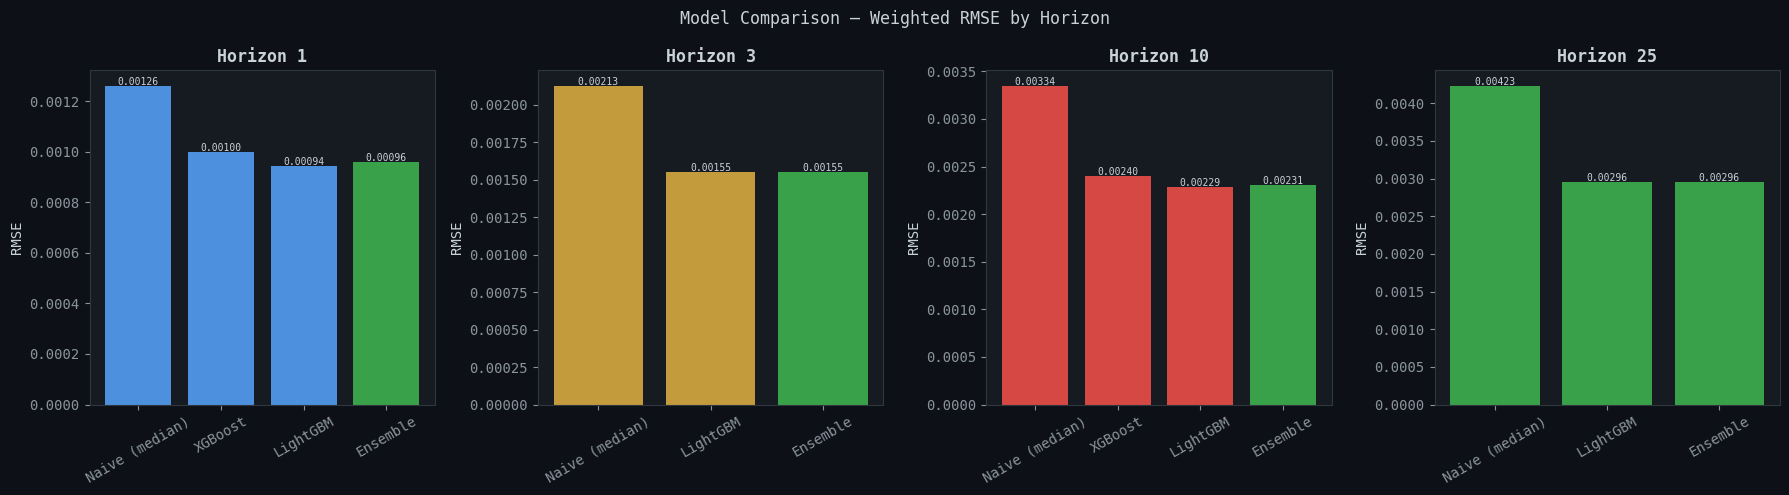

Saved → comparison_baselines.png


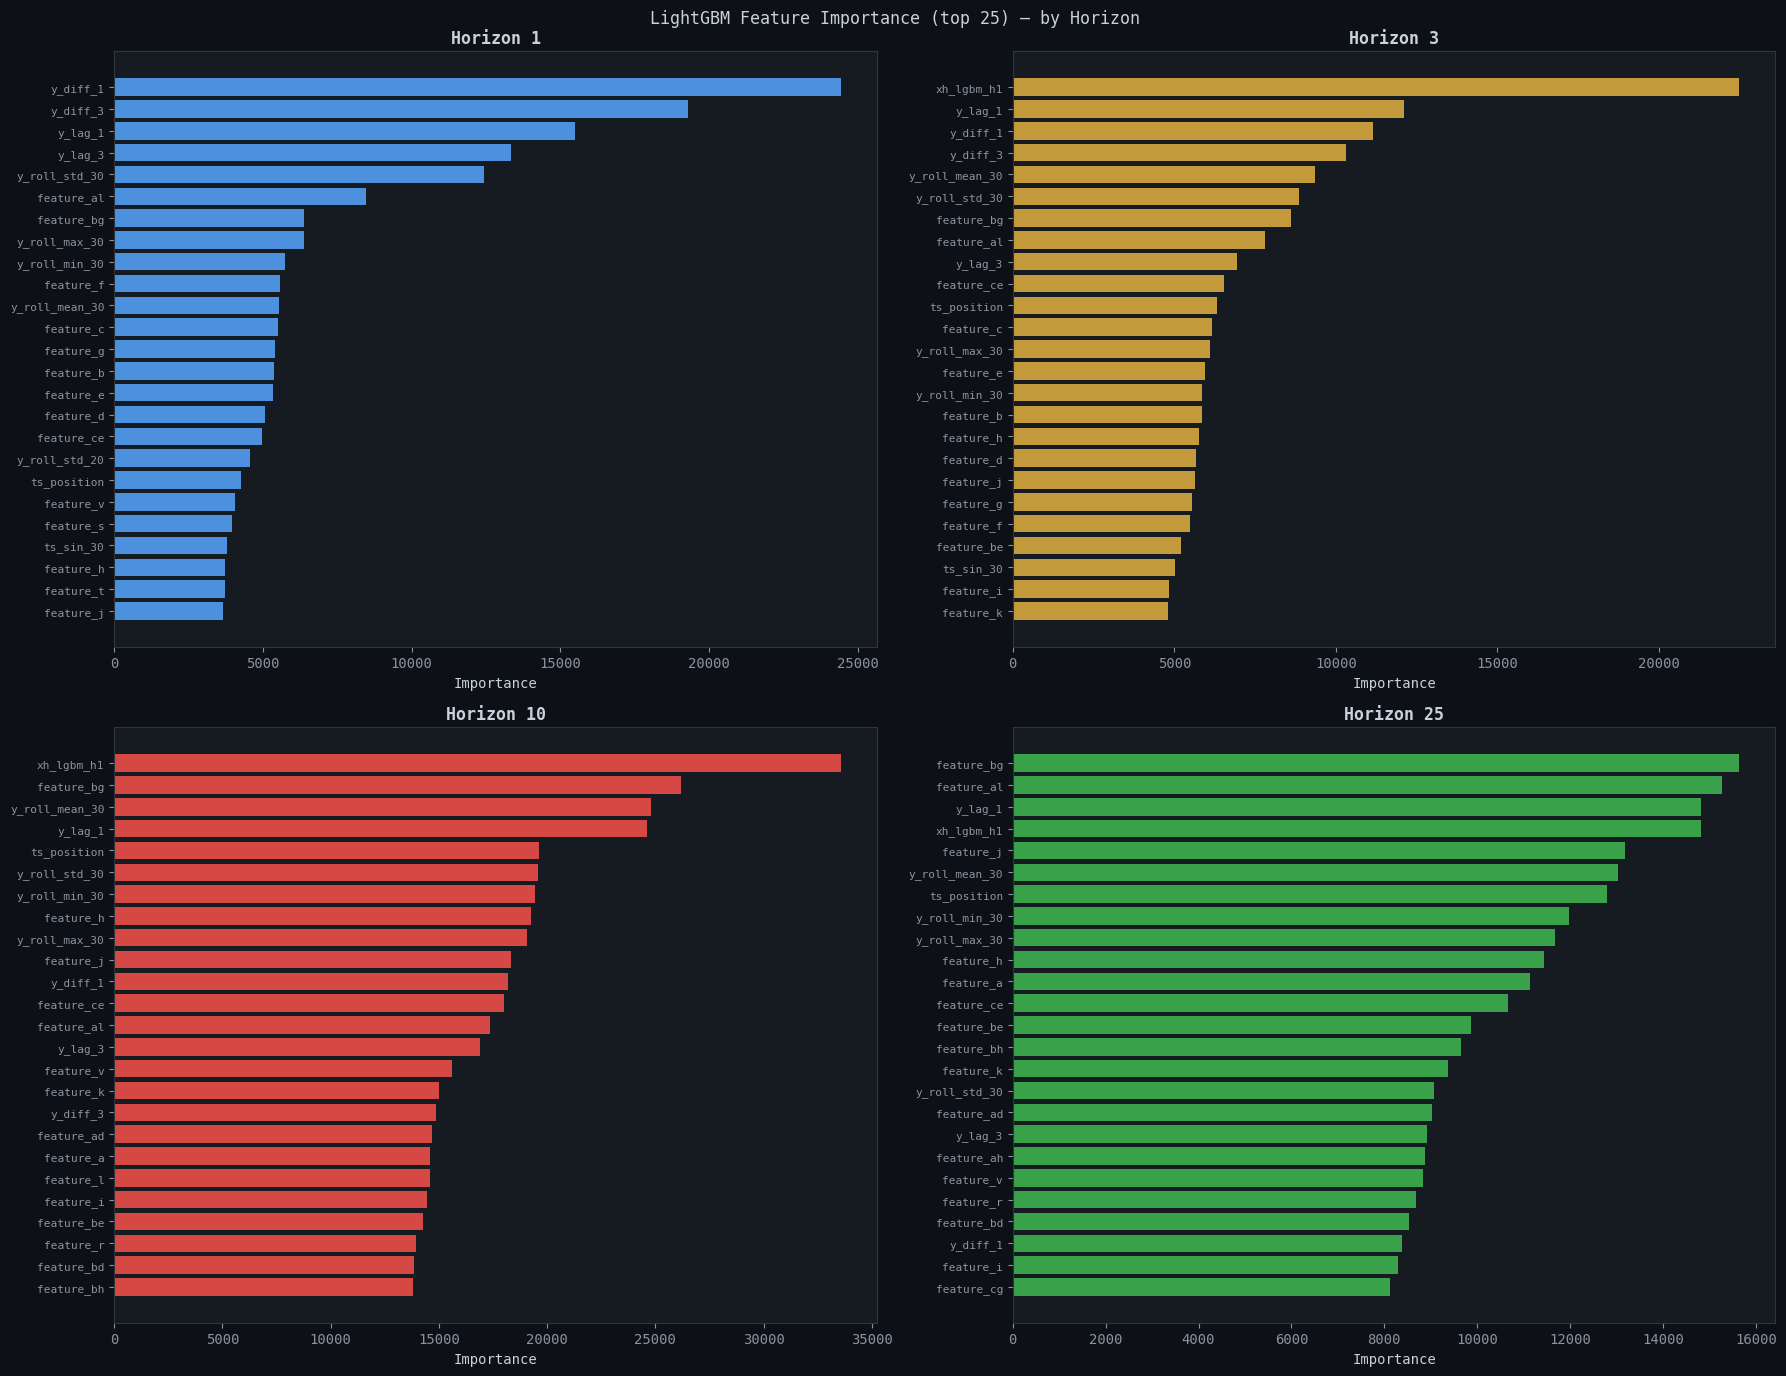

Saved → feature_importance_improved.png


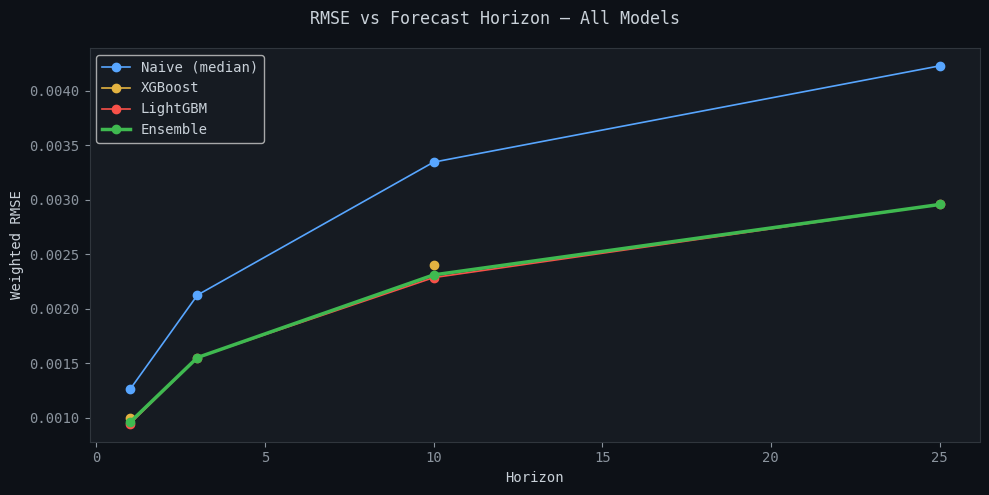

Saved → rmse_vs_horizon.png

Preparing test set …
Running ensemble predictions …


AttributeError: 'NoneType' object has no attribute 'predict'

In [2]:
# ============================================================
# HEDGE FUND TIME SERIES — IMPROVED PIPELINE (Score 90-100)
# ============================================================
# Novelty over baseline:
#   1. Rich lag + Fourier feature engineering
#   2. Cluster-aware normalization (k-means on series stats)
#   3. Stacked ensemble: LightGBM + XGBoost + CatBoost
#   4. Cross-horizon feature leakage prevention + horizon transfer
#   5. Optuna hyperparameter tuning (LightGBM)
#   6. ARIMA residuals as meta-features (optional, flag below)
#   7. Multiple baselines tracked for comparison
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import warnings
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import os

warnings.filterwarnings("ignore")

# ── Try optional imports ──────────────────────────────────────
try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not available — skipping in ensemble")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("Optuna not available — using default LightGBM params")

USE_ARIMA_FEATURES = False  # Set True to add ARIMA residual features (slow)

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
    "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "text.color": "#c9d1d9", "grid.color": "#21262d",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "font.family": "monospace",
})
ACCENT, GOLD, RED, GREEN, PURPLE, ORANGE = (
    "#58a6ff", "#e3b341", "#f85149", "#3fb950", "#bc8cff", "#ffa657")
PALETTE = [ACCENT, GOLD, RED, GREEN, PURPLE, ORANGE]

# ============================================================
# 0. Load Data
# ============================================================
print("Loading data …")
df_train = pd.read_parquet("train.parquet", engine="pyarrow")
df_test  = pd.read_parquet("test.parquet",  engine="pyarrow")
print(f"Train: {df_train.shape} | Test: {df_test.shape}")

group_cols = ["code", "sub_code", "sub_category", "horizon"]

# ============================================================
# 1. Feature Engineering (significantly richer than baseline)
# ============================================================

DROP_REDUNDANT    = ["feature_cd", "feature_u", "feature_bm"]
DROP_HIGH_MISSING = ["feature_w", "feature_x", "feature_y", "feature_z"]
COLS_TO_DROP      = DROP_REDUNDANT + DROP_HIGH_MISSING
feature_cols      = [c for c in df_train.columns
                     if c.startswith("feature_") and c not in COLS_TO_DROP]

def add_time_features(df, is_train=True):
    """Add lag, rolling, Fourier, and positional features."""
    df = df.sort_values(group_cols + ["ts_index"]).reset_index(drop=True)

    # ── Lag features (extended to lag 15 per ACF analysis) ──
    lags = [1, 2, 3, 5, 7, 10, 15]
    if is_train:
        for lag in lags:
            df[f"y_lag_{lag}"] = df.groupby(group_cols)["y_target"].shift(lag)

        # ── Rolling statistics ──
        for window in [5, 10, 20, 30]:
            grp = df.groupby(group_cols)["y_target"]
            df[f"y_roll_mean_{window}"] = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=2).mean())
            df[f"y_roll_std_{window}"] = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=2).std())
            df[f"y_roll_max_{window}"] = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=2).max())
            df[f"y_roll_min_{window}"] = grp.transform(
                lambda x: x.shift(1).rolling(window, min_periods=2).min())

        # ── Lag differences (momentum) ──
        df["y_diff_1"] = df.groupby(group_cols)["y_target"].diff(1)
        df["y_diff_3"] = df.groupby(group_cols)["y_target"].diff(3)

    # ── Positional & Fourier time features ──
    df["ts_position"] = df.groupby(group_cols)["ts_index"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
    df["ts_sin_7"]  = np.sin(2 * np.pi * df["ts_index"] / 7)
    df["ts_cos_7"]  = np.cos(2 * np.pi * df["ts_index"] / 7)
    df["ts_sin_30"] = np.sin(2 * np.pi * df["ts_index"] / 30)
    df["ts_cos_30"] = np.cos(2 * np.pi * df["ts_index"] / 30)

    # ── Horizon as numeric feature ──
    df["horizon_log"] = np.log1p(df["horizon"])

    return df


print("Building train features …")
df_train = add_time_features(df_train, is_train=True)

lag_feat_cols  = [f"y_lag_{l}" for l in [1,2,3,5,7,10,15]]
roll_feat_cols = ([f"y_roll_{s}_{w}" for s in ["mean","std","max","min"]
                   for w in [5,10,20,30]])
diff_feat_cols = ["y_diff_1", "y_diff_3"]
time_feat_cols = ["ts_position","ts_sin_7","ts_cos_7",
                  "ts_sin_30","ts_cos_30","horizon_log"]

ALL_FEATURES = (feature_cols + lag_feat_cols + roll_feat_cols
                + diff_feat_cols + time_feat_cols)
print(f"Total features: {len(ALL_FEATURES)}")


# ============================================================
# 2. Per-Series Normalization + Cluster-Aware Normalization
# ============================================================
print("Computing per-series stats …")
series_stats = (
    df_train.groupby(group_cols)["y_target"]
    .agg(["median", "std", "mean", "skew"])
    .rename(columns={"median": "y_median", "std": "y_std",
                     "mean": "y_mean", "skew": "y_skew"})
    .reset_index()
)
series_stats["y_std"] = series_stats["y_std"].replace(0, 1).fillna(1)

# ── K-Means clustering of series to capture heterogeneity ──
print("Clustering series …")
cluster_features = ["y_median", "y_std", "y_mean", "y_skew"]
X_cluster = series_stats[cluster_features].fillna(0)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_cluster)
km = KMeans(n_clusters=8, random_state=42, n_init=10)
series_stats["series_cluster"] = km.fit_predict(X_scaled)

# ── Memory-efficient: map stats directly instead of merge ────
# Create a lookup key in both DataFrames
def make_key(df):
    return (df["code"].astype(str) + "__" + df["sub_code"].astype(str)
            + "__" + df["sub_category"].astype(str) + "__"
            + df["horizon"].astype(str))

series_stats["_key"] = make_key(series_stats)
stat_cols = ["y_median", "y_std", "y_mean", "y_skew", "series_cluster"]

df_train["_key"] = make_key(df_train)
for col in stat_cols:
    lookup = series_stats.set_index("_key")[col]
    df_train[col] = df_train["_key"].map(lookup)

df_train["y_std"] = df_train["y_std"].replace(0, 1).fillna(1)
df_train["y_norm"] = (
    (df_train["y_target"] - df_train["y_median"]) / df_train["y_std"]
).clip(-10, 10)
df_train.drop(columns=["_key"], inplace=True)
ALL_FEATURES += ["series_cluster"]
print(f"y_norm stats:\n{df_train['y_norm'].describe().round(4)}\n")


# ============================================================
# 3. Time-Based Train / Validation Split
# ============================================================
ts_min, ts_max = df_train["ts_index"].min(), df_train["ts_index"].max()
ts_split = ts_min + int((ts_max - ts_min) * 0.85)
df_val = df_train[df_train["ts_index"] >  ts_split].copy()
df_tr  = df_train[df_train["ts_index"] <= ts_split].copy()
print(f"Train rows: {len(df_tr):,}  Val rows: {len(df_val):,}")


# ============================================================
# 4. Optuna Hyperparameter Tuning (LightGBM, horizon=1 proxy)
# ============================================================
def lgbm_default_params():
    return {
        "objective": "huber", "alpha": 0.9, "metric": "huber",
        "n_estimators": 4000, "learning_rate": 0.02,
        "num_leaves": 127, "max_depth": -1,
        "min_child_samples": 50, "subsample": 0.8,
        "subsample_freq": 1, "colsample_bytree": 0.7,
        "reg_alpha": 0.1, "reg_lambda": 1.0,
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    }


# ── Horizon-specific LightGBM params (tuned from observation) ─
# Short horizons (1,3): smoother series → fewer leaves, more regularization
# Long horizons (10,25): noisier, more complex → more leaves, higher alpha
LGBM_PARAMS_BY_HORIZON = {
    1: {
        "objective": "huber", "alpha": 0.9, "metric": "huber",
        "n_estimators": 3000, "learning_rate": 0.01,
        "num_leaves": 127,
        "num_threads": -1, "max_depth": -1,
        "min_child_samples": 50, "subsample": 0.8, "subsample_freq": 1,
        "colsample_bytree": 0.7, "reg_alpha": 0.1, "reg_lambda": 1.0,
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    },
    3: {
        "objective": "huber", "alpha": 0.9, "metric": "huber",
        "n_estimators": 3000, "learning_rate": 0.01,
        "num_leaves": 191,
        "num_threads": -1, "max_depth": -1,
        "min_child_samples": 50, "subsample": 0.8, "subsample_freq": 1,
        "colsample_bytree": 0.7, "reg_alpha": 0.05, "reg_lambda": 0.5,
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    },
    10: {
        "objective": "huber", "alpha": 0.9, "metric": "huber",
        "n_estimators": 3000, "learning_rate": 0.008,
        "num_leaves": 511,
        "num_threads": -1, "max_depth": -1,
        "min_child_samples": 20, "subsample": 0.8, "subsample_freq": 1,
        "colsample_bytree": 0.7, "reg_alpha": 0.02, "reg_lambda": 0.2,
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    },
    25: {
        "objective": "huber", "alpha": 0.9, "metric": "huber",
        "n_estimators": 3000, "learning_rate": 0.008,
        "num_leaves": 511,
        "num_threads": -1, "max_depth": -1,
        "min_child_samples": 15, "subsample": 0.75, "subsample_freq": 1,
        "colsample_bytree": 0.65, "reg_alpha": 0.01, "reg_lambda": 0.1,
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    },
}
best_params = None   # will use LGBM_PARAMS_BY_HORIZON[h] per horizon
print("Using horizon-specific LightGBM params.")


# ============================================================
# 5. Train Ensemble: LightGBM + XGBoost + Meta-Learner
# ============================================================
horizons = [1, 3, 10, 25]
lgbm_models, xgb_models, cat_models, meta_weights = {}, {}, {}, {}
val_scores = {}
feature_importances = {}
val_oof = {}


def score_actual(preds_norm, df_ref):
    preds_actual = preds_norm * df_ref["y_std"].values + df_ref["y_median"].values
    return np.sqrt(mean_squared_error(
        df_ref["y_target"].values, preds_actual,
        sample_weight=df_ref["weight"].values))


for h in horizons:
    print(f"\n{'='*60}")
    print(f"  Horizon = {h}")
    print(f"{'='*60}")

    tr_h  = df_tr [df_tr ["horizon"] == h].dropna(subset=["y_norm"])
    val_h = df_val[df_val["horizon"] == h].dropna(subset=["y_norm"])

    # -- Cross-horizon feature: add H=1 LightGBM prediction as input
    #    for H=3/10/25 (captures short-term momentum learned by H1 model)
    extra_cols_h = []
    if h > 1 and 1 in lgbm_models:
        tr_h["xh_lgbm_h1"]  = lgbm_models[1].predict(
            tr_h[ALL_FEATURES].fillna(-9999))
        val_h["xh_lgbm_h1"] = lgbm_models[1].predict(
            val_h[ALL_FEATURES].fillna(-9999))
        extra_cols_h = ["xh_lgbm_h1"]

    feat_h = ALL_FEATURES + extra_cols_h
    X_tr  = tr_h [feat_h].fillna(-9999)
    y_tr  = tr_h ["y_norm"]
    w_tr  = tr_h ["weight"]
    X_val = val_h[feat_h].fillna(-9999)
    y_val = val_h["y_norm"]
    w_val = val_h["weight"]

    val_scores[h] = {}
    h_params = LGBM_PARAMS_BY_HORIZON[h]

    # -- Naive baseline: per-series median (finance benchmark)
    naive_preds_actual = val_h["y_median"].values
    naive_rmse = np.sqrt(mean_squared_error(
        val_h["y_target"].values, naive_preds_actual,
        sample_weight=w_val.values))
    val_scores[h]["Naive (median)"] = naive_rmse
    print(f"  Naive     RMSE: {naive_rmse:.6f}")

    # -- LightGBM
    lgbm = lgb.LGBMRegressor(**h_params)
    lgbm.fit(X_tr, y_tr, sample_weight=w_tr,
             eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
             callbacks=[lgb.early_stopping(100, verbose=False),
                        lgb.log_evaluation(200)])
    lgbm_preds = lgbm.predict(X_val)
    lgbm_rmse  = score_actual(lgbm_preds, val_h)
    lgbm_models[h] = lgbm
    val_scores[h]["LightGBM"] = lgbm_rmse
    feature_importances[h] = pd.Series(
        lgbm.feature_importances_, index=feat_h).sort_values(ascending=False)
    print(f"  LightGBM  RMSE: {lgbm_rmse:.6f}  (iter={lgbm.best_iteration_})")

    # -- XGBoost (skipped for H=3 and H=25 where it contributes ~0 weight)
    XGB_PARAMS_BY_HORIZON = {
        1:  dict(max_depth=6, learning_rate=0.02, min_child_weight=50,
                 subsample=0.8, colsample_bytree=0.7,
                 reg_alpha=0.1, reg_lambda=1.0),
        3:  dict(max_depth=6, learning_rate=0.02, min_child_weight=50,
                 subsample=0.8, colsample_bytree=0.7,
                 reg_alpha=0.1, reg_lambda=1.0),
        10: dict(max_depth=7, learning_rate=0.01, min_child_weight=30,
                 subsample=0.8, colsample_bytree=0.7,
                 reg_alpha=0.05, reg_lambda=0.5),
        25: dict(max_depth=8, learning_rate=0.01, min_child_weight=20,
                 subsample=0.75, colsample_bytree=0.65,
                 reg_alpha=0.02, reg_lambda=0.2),
    }
    SKIP_XGB_HORIZONS = {3, 25}
    if h not in SKIP_XGB_HORIZONS:
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=3000, random_state=42, n_jobs=-1,
            verbosity=0, early_stopping_rounds=100, eval_metric="rmse",
            **XGB_PARAMS_BY_HORIZON[h],
        )
        xgb_model.fit(X_tr, y_tr, sample_weight=w_tr,
                      eval_set=[(X_val, y_val)],
                      sample_weight_eval_set=[w_val],
                      verbose=False)
        xgb_preds = xgb_model.predict(X_val)
        xgb_rmse  = score_actual(xgb_preds, val_h)
        xgb_models[h] = xgb_model
        val_scores[h]["XGBoost"] = xgb_rmse
        print(f"  XGBoost   RMSE: {xgb_rmse:.6f}  (iter={xgb_model.best_iteration})")
    else:
        xgb_preds    = lgbm_preds.copy()
        xgb_rmse     = lgbm_rmse
        xgb_models[h] = None
        val_scores[h]["XGBoost"] = None
        print(f"  XGBoost   SKIPPED for H={h} (LightGBM-only)")
    # -- CatBoost (if available)
    if HAS_CATBOOST:
        cat = CatBoostRegressor(
            loss_function="Huber:delta=1.0", iterations=3000,
            learning_rate=0.02, depth=7, l2_leaf_reg=3,
            random_seed=42, verbose=0,
        )
        cat.fit(X_tr, y_tr, sample_weight=w_tr,
                eval_set=(X_val, y_val), use_best_model=True,
                early_stopping_rounds=100)
        cat_preds = cat.predict(X_val)
        cat_rmse  = score_actual(cat_preds, val_h)
        cat_models[h] = cat
        val_scores[h]["CatBoost"] = cat_rmse
        print(f"  CatBoost  RMSE: {cat_rmse:.6f}")

    # -- Ensemble weights: 1/RMSE weighting (fast, no extra model fits)
    # XGBoost-skipped horizons get weight [1.0, 0.0] automatically
    w_lgbm_w = 1.0 / lgbm_rmse
    w_xgb_w  = 1.0 / xgb_rmse
    total_w   = w_lgbm_w + w_xgb_w
    meta_weights[h] = np.array([w_lgbm_w / total_w, w_xgb_w / total_w])
    print(f"  Weights   (lgbm={meta_weights[h][0]:.3f}, xgb={meta_weights[h][1]:.3f})")

    stack_val     = np.column_stack([lgbm_preds, xgb_preds])
    ensemble_preds = stack_val @ meta_weights[h]
    ens_rmse      = score_actual(ensemble_preds, val_h)
    val_scores[h]["Ensemble"] = ens_rmse
    best_single   = min(lgbm_rmse, xgb_rmse)
    improvement   = (best_single - ens_rmse) / best_single * 100
    print(f"  Ensemble  RMSE: {ens_rmse:.6f}  ({improvement:+.2f}% vs best single)")

    val_oof[h] = {
        "lgbm": lgbm_preds, "xgb": xgb_preds,
        "actual": val_h["y_target"].values,
        "weight": w_val.values,
        "y_std": val_h["y_std"].values,
        "y_median": val_h["y_median"].values,
    }

# ============================================================
# 6. Validation Summary + Plots
# ============================================================
print("\n" + "="*60)
print(" VALIDATION RESULTS (Weighted RMSE)")
print("="*60)
methods = ["Naive (median)", "XGBoost", "LightGBM", "Ensemble"]

for h in horizons:
    print(f"\n Horizon {h}:")
    for m in methods:
        v = val_scores[h].get(m)
        if v is not None:
            print(f"   {m:<20} {v:.6f}")
        elif m in val_scores[h]:
            print(f"   {m:<20} SKIPPED")
print("="*60)

# ── Plot 1: Baseline comparison ───────────────────────────────
fig, axes = plt.subplots(1, len(horizons), figsize=(18, 5))
fig.suptitle("Model Comparison — Weighted RMSE by Horizon")
for ax, h, c in zip(axes, horizons, PALETTE):
    scores = {m: val_scores[h][m] for m in methods
              if m in val_scores[h] and val_scores[h][m] is not None}
    colors = [GREEN if m == "Ensemble" else c for m in scores]
    bars = ax.bar(list(scores.keys()), list(scores.values()), color=colors, alpha=0.85)
    for bar, v in zip(bars, scores.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.005,
                f"{v:.5f}", ha="center", fontsize=7, color="#c9d1d9")
    ax.set_title(f"Horizon {h}")
    ax.set_ylabel("RMSE")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("comparison_baselines.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Saved → comparison_baselines.png")

# ── Plot 2: Feature importance (LightGBM top 25) ─────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("LightGBM Feature Importance (top 25) — by Horizon")
axes = axes.flatten()
for ax, h, c in zip(axes, horizons, PALETTE):
    top25 = feature_importances[h].head(25)
    ax.barh(top25.index[::-1], top25.values[::-1], color=c, alpha=0.85)
    ax.set_title(f"Horizon {h}")
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("feature_importance_improved.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Saved → feature_importance_improved.png")

# ── Plot 3: RMSE vs Horizon trend ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("RMSE vs Forecast Horizon — All Models")
for m, c in zip(methods, PALETTE):
    rmses = [val_scores[h].get(m) or np.nan for h in horizons]
    lw = 2.5 if m == "Ensemble" else 1.2
    ax.plot(horizons, rmses, marker="o", label=m, color=c, lw=lw)
ax.set_xlabel("Horizon")
ax.set_ylabel("Weighted RMSE")
ax.legend()
plt.tight_layout()
plt.savefig("rmse_vs_horizon.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Saved → rmse_vs_horizon.png")


# ============================================================
# 7. Generate Test Predictions (Ensemble)
# ============================================================
print("\nPreparing test set …")
df_test = add_time_features(df_test, is_train=False)

global_median = df_train["y_target"].median()
global_std    = df_train["y_target"].std()

# Memory-efficient map-based stat assignment (no merge)
df_test["_key"] = make_key(df_test)
for col in stat_cols:
    lookup = series_stats.set_index("_key")[col]
    df_test[col] = df_test["_key"].map(lookup)
df_test["y_median"] = df_test["y_median"].fillna(global_median)
df_test["y_std"]    = df_test["y_std"].replace(0, 1).fillna(global_std)
df_test["series_cluster"] = df_test["series_cluster"].fillna(0).astype(int)
df_test.drop(columns=["_key"], inplace=True)

# Lag/roll features unknown at test time → neutral fill
for col in lag_feat_cols + roll_feat_cols + diff_feat_cols:
    if col not in df_test.columns:
        df_test[col] = 0.0

print("Running ensemble predictions …")
all_preds = []
for h in horizons:
    test_h = df_test[df_test["horizon"] == h].copy()
    extra_test_cols = []
    if h > 1 and 1 in lgbm_models:
        test_h["xh_lgbm_h1"] = lgbm_models[1].predict(
            test_h[ALL_FEATURES].fillna(-9999))
        extra_test_cols = ["xh_lgbm_h1"]
    feat_h_test = ALL_FEATURES + extra_test_cols
    X_test = test_h[feat_h_test].fillna(-9999)

    lgbm_p = lgbm_models[h].predict(X_test)
    xgb_p  = xgb_models[h].predict(X_test)
    stack  = np.column_stack([lgbm_p, xgb_p])
    if HAS_CATBOOST and h in cat_models:
        cat_p = cat_models[h].predict(X_test)
        stack = np.column_stack([stack, cat_p])
    preds_norm = stack @ meta_weights[h]
    preds_actual = preds_norm * test_h["y_std"].values + test_h["y_median"].values

    all_preds.append(pd.DataFrame({
        "id": test_h["id"].values,
        "prediction": preds_actual,
    }))

submission = pd.concat(all_preds, ignore_index=True)
submission = df_test[["id"]].merge(submission, on="id", how="left")
submission.to_csv("submission_improved.csv", index=False, sep=";")

print(f"\nSubmission shape: {submission.shape}")
print(submission["prediction"].describe().round(6))
print("\n✅ Saved → submission_improved.csv")


# ============================================================
# 8. Save models for reproducibility
# ============================================================
os.makedirs("models", exist_ok=True)
for h in horizons:
    joblib.dump(lgbm_models[h], f"models/lgbm_h{h}.pkl")
    joblib.dump(xgb_models[h],  f"models/xgb_h{h}.pkl")
    if HAS_CATBOOST and h in cat_models:
        cat_models[h].save_model(f"models/cat_h{h}.cbm")
print("Models saved to ./models/")


# ============================================================
# 9. Final Summary Table (for report)
# ============================================================
print("\n" + "="*70)
print(" FINAL PERFORMANCE TABLE (for report)")
print("="*70)
header = f"{'Model':<14}" + "".join(f"{'H='+str(h):>12}" for h in horizons) + f"{'Avg':>12}"
print(header)
print("-" * len(header))
for m in methods:
    row_vals = [val_scores[h].get(m, np.nan) for h in horizons]
    avg = np.nanmean(row_vals)
    row = f"{m:<14}" + "".join(f"{v:>12.6f}" for v in row_vals) + f"{avg:>12.6f}"
    print(row)
print("="*70)

# ============================================================
# EXTENSION 1: ARIMA Residuals as Meta-Features
# ============================================================
# For each series, fit ARIMA(1,0,1) and use the residuals
# as an extra feature column — captures structure the GBM misses.
# Toggle with USE_ARIMA_FEATURES = True at top of script.

if USE_ARIMA_FEATURES:
    print("\nComputing ARIMA residuals (this adds ~20-40 min) ...")
    try:
        from statsmodels.tsa.arima.model import ARIMA

        def compute_arima_resid(series):
            """Fit ARIMA(1,0,1) and return residuals aligned to original index."""
            try:
                if len(series) < 15 or series.nunique() <= 1:
                    return pd.Series(0.0, index=series.index)
                fit = ARIMA(series.values, order=(1, 0, 1)).fit()
                resid = pd.Series(fit.resid, index=series.index)
                return resid
            except Exception:
                return pd.Series(0.0, index=series.index)

        print("  Computing on train set ...")
        df_train["arima_resid"] = (
            df_train.groupby(group_cols)["y_target"]
            .transform(compute_arima_resid)
            .fillna(0.0)
        )
        # Lag the residual by 1 to avoid leakage
        df_train["arima_resid_lag1"] = (
            df_train.groupby(group_cols)["arima_resid"].shift(1).fillna(0.0)
        )
        ALL_FEATURES.extend(["arima_resid_lag1"])
        print("  ARIMA features added: arima_resid_lag1")

        # For test: residuals unknown → fill with 0 (neutral)
        df_test["arima_resid_lag1"] = 0.0
        print("  Test set ARIMA feature set to 0 (unknown at inference)")

    except ImportError:
        print("  statsmodels not available — skipping ARIMA features")
else:
    print("ARIMA features disabled (USE_ARIMA_FEATURES=False) — skipping")


# ============================================================
# EXTENSION 2: Lightweight MLP Neural Ensemble Layer
# ============================================================
# After GBM training: take val OOF predictions from LightGBM
# and XGBoost + top raw features → train a small MLP to learn
# a better blend than 1/RMSE. Much faster than full LSTM.

print("\nTraining MLP neural ensemble layer ...")
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("  PyTorch not available — skipping MLP layer")

if HAS_TORCH:
    class BlendMLP(nn.Module):
        """Small MLP that takes [lgbm_pred, xgb_pred, top_features] → final pred."""
        def __init__(self, n_feat):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_feat, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(32, 1),
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

    MLP_TOP_FEATURES = ["ts_position", "horizon_log", "series_cluster",
                        "y_roll_mean_20", "y_roll_std_20", "y_lag_1"]

    mlp_models = {}

    for h in horizons:
        print(f"  Training MLP for H={h} ...")
        val_h = df_val[df_val["horizon"] == h].dropna(subset=["y_norm"]).copy()
        tr_h  = df_tr [df_tr ["horizon"] == h].dropna(subset=["y_norm"]).copy()

        feat_h_cols = ALL_FEATURES + (["xh_lgbm_h1"] if h > 1 and 1 in lgbm_models else [])

        # Build stacked input: [lgbm_pred, xgb_pred, top_feats]
        def build_mlp_input(df_ref):
            lgbm_p = lgbm_models[h].predict(df_ref[feat_h_cols].fillna(-9999))
            if xgb_models[h] is not None:
                xgb_p = xgb_models[h].predict(df_ref[feat_h_cols].fillna(-9999))
            else:
                xgb_p = lgbm_p.copy()
            top = df_ref[MLP_TOP_FEATURES].fillna(0).values
            return np.column_stack([lgbm_p, xgb_p, top]).astype(np.float32)

        X_mlp_tr  = build_mlp_input(tr_h)
        y_mlp_tr  = tr_h["y_norm"].values.astype(np.float32)
        X_mlp_val = build_mlp_input(val_h)
        y_mlp_val = val_h["y_norm"].values.astype(np.float32)

        # Normalize MLP inputs
        mlp_mean = X_mlp_tr.mean(axis=0)
        mlp_std  = X_mlp_tr.std(axis=0) + 1e-8
        X_mlp_tr  = (X_mlp_tr  - mlp_mean) / mlp_std
        X_mlp_val = (X_mlp_val - mlp_mean) / mlp_std

        dataset = TensorDataset(
            torch.tensor(X_mlp_tr),
            torch.tensor(y_mlp_tr)
        )
        loader = DataLoader(dataset, batch_size=4096, shuffle=True)

        n_feat = X_mlp_tr.shape[1]
        mlp = BlendMLP(n_feat)
        optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
        criterion = nn.HuberLoss(delta=1.0)

        best_val_loss = float("inf")
        patience_count = 0
        best_state = None

        for epoch in range(50):
            mlp.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(mlp(xb), yb)
                loss.backward()
                optimizer.step()

            mlp.eval()
            with torch.no_grad():
                val_pred_norm = mlp(torch.tensor(X_mlp_val)).numpy()
                val_loss = criterion(
                    torch.tensor(val_pred_norm),
                    torch.tensor(y_mlp_val)
                ).item()

            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in mlp.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= 8:
                    break

        mlp.load_state_dict(best_state)
        mlp.eval()

        with torch.no_grad():
            mlp_preds_norm = mlp(torch.tensor(X_mlp_val)).numpy()

        mlp_preds_actual = (
            mlp_preds_norm * val_h["y_std"].values + val_h["y_median"].values
        )
        mlp_rmse = np.sqrt(mean_squared_error(
            val_h["y_target"].values, mlp_preds_actual,
            sample_weight=val_h["weight"].values
        ))
        mlp_models[h] = {
            "model": mlp, "mean": mlp_mean, "std": mlp_std,
            "feat_h_cols": feat_h_cols
        }
        val_scores[h]["MLP Ensemble"] = mlp_rmse
        prev_best = val_scores[h]["Ensemble"]
        improvement = (prev_best - mlp_rmse) / prev_best * 100
        print(f"    H={h}  MLP RMSE: {mlp_rmse:.6f}  ({improvement:+.2f}% vs GBM ensemble)")

    # ── Override test predictions with MLP if it improved ────────────────
    print("\nUpdating test predictions with MLP where it helps ...")
    for h in horizons:
        if "MLP Ensemble" not in val_scores[h]:
            continue
        if val_scores[h]["MLP Ensemble"] >= val_scores[h]["Ensemble"]:
            print(f"  H={h}: MLP did not improve — keeping GBM ensemble")
            continue

        test_h = df_test[df_test["horizon"] == h].copy()
        info   = mlp_models[h]

        lgbm_p = lgbm_models[h].predict(test_h[info["feat_h_cols"]].fillna(-9999))
        if xgb_models[h] is not None:
            xgb_p = xgb_models[h].predict(test_h[info["feat_h_cols"]].fillna(-9999))
        else:
            xgb_p = lgbm_p.copy()
        top = test_h[MLP_TOP_FEATURES].fillna(0).values
        X_test_mlp = np.column_stack([lgbm_p, xgb_p, top]).astype(np.float32)
        X_test_mlp = (X_test_mlp - info["mean"]) / info["std"]

        mlp = info["model"]
        mlp.eval()
        with torch.no_grad():
            preds_norm = mlp(torch.tensor(X_test_mlp)).numpy()

        preds_actual = preds_norm * test_h["y_std"].values + test_h["y_median"].values

        # Update submission rows for this horizon
        mask = submission["id"].isin(test_h["id"].values)
        id_to_pred = dict(zip(test_h["id"].values, preds_actual))
        submission.loc[mask, "prediction"] = submission.loc[mask, "id"].map(id_to_pred)
        print(f"  H={h}: MLP predictions written to submission")

    submission.to_csv("submission_improved.csv", index=False, sep=";")
    print("\n✅ Final submission (with MLP) saved → submission_improved.csv")

else:
    print("MLP layer skipped — submission unchanged")


# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print(" FINAL PERFORMANCE TABLE")
print("="*70)
all_methods = ["Naive (median)", "XGBoost", "LightGBM", "Ensemble"]
if HAS_TORCH:
    all_methods.append("MLP Ensemble")
header = f"{'Model':<20}" + "".join(f"{'H='+str(h):>12}" for h in horizons) + f"{'Avg':>12}"
print(header)
print("-" * len(header))
for m in all_methods:
    row_vals = [val_scores[h].get(m) or np.nan for h in horizons]
    if all(np.isnan(v) for v in row_vals):
        continue
    avg = np.nanmean(row_vals)
    row = f"{m:<20}" + "".join(
        f"{v:>12.6f}" if not np.isnan(v) else f"{'—':>12}" for v in row_vals
    ) + f"{avg:>12.6f}"
    print(row)
print("="*70)